# Reprodução do Experimento SOME/IP IDS — CTGAN + XGBoost

Notebook preparado para Google Colab.

Estrutura esperada:

```text
/content/datasets/
  X_train.npy
  y_train.npy
  X_test.npy
  y_test.npy
```

Objetivo:

1. Validar distribuição do dataset.
2. Criar teste balanceado por downsampling.
3. Treinar baseline XGBoost sem CTGAN.
4. Criar validação de threshold e normalizar features por Min-Max.
5. Treinar CTGAN apenas com ataques do treino.
5. Gerar ataques sintéticos até balancear o treino.
6. Treinar XGBoost com hiperparâmetros do artigo.
7. Avaliar em cenário realista desbalanceado e cenário controlado balanceado.

Referência de parâmetros do artigo:

- XGBoost: 1000 árvores, learning rate 0.05, max depth 6, subsample 0.8, colsample 0.8, min child weight 1, lambda 1, gamma 0.
- CTGAN: embedding_dim 128, generator/critic 256/256, batch_size 500, pac 10, epochs 100.


## 0. Instalação das dependências

No Colab, rode esta célula primeiro. Se usar GPU, vá em **Runtime > Change runtime type > GPU**.


In [1]:
!pip -q install xgboost scikit-learn pandas numpy matplotlib sdv ctgan joblib pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.7/204.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 242.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 173.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 13.4 MB/s eta 0:00:00


In [ ]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 78.0 MB/s eta 0:00:00


In [2]:
!pip show ctgan

Name: ctgan
Version: 0.12.1
Summary: Create tabular synthetic data using a conditional GAN
Home-page: 
Author: 
Author-email: "DataCebo, Inc." <info@sdv.dev>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pandas, rdt, torch, tqdm
Required-by: sdv


## 1. Imports e configuração global

In [3]:
import os
import gc
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample

import xgboost as xgb
import joblib

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
DATA_DIR = Path('/content/datasets')
OUT_DIR = Path('/content/outputs_someip_xgboost')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_DIR:', DATA_DIR)
print('OUT_DIR:', OUT_DIR)


DATA_DIR: /content/datasets
OUT_DIR: /content/outputs_someip_xgboost


## 2. Parâmetros de execução

Para reprodução completa, deixe `RUN_FULL_CTGAN = True` e `CTGAN_EPOCHS = 100`.

Para validar rapidamente o pipeline, use `QUICK_MODE = True`.


In [ ]:
# Modo rápido para testar se tudo funciona antes do treino completo.
QUICK_MODE = False

# CTGAN completo pode demorar bastante. Em Colab gratuito pode ser pesado.
RUN_FULL_CTGAN = True

# Reproduz o paper com avaliação "training-side":
# - separa uma validação estratificada dentro do treino para escolher threshold;
# - o test set continua intocado.
USE_VALIDATION_SPLIT = True
VALIDATION_SIZE = 0.10

# Normalização Min-Max descrita na Seção 5.3 do artigo.
# Importante principalmente para CTGAN, pois XGBoost é pouco sensível à escala,
# mas o gerador tabular é bastante sensível.
APPLY_MINMAX_NORMALIZATION = True
CLIP_TEST_TO_TRAIN_RANGE = True

# Estratégia de geração sintética:
# 'paper_table'  -> gera aproximadamente N_normal sintéticos.
#                   Isso reproduz a Tabela 3: normal=6.285.515 e attack real+synth=7.116.673.
# 'balanced_final' -> gera até ataque_final == normal.
SYNTHETIC_STRATEGY = 'paper_table'

# Clipping dos sintéticos não é descrito no paper.
CLIP_SYNTHETIC_TO_ATTACK_RANGE = False

# Thresholds adicionais para análise operacional de IDS.
TARGET_RECALL = 0.97
FBETA_BETA = 2.0

# Parâmetros CTGAN do artigo
CTGAN_EPOCHS = 100
CTGAN_BATCH_SIZE = 500
CTGAN_EMBEDDING_DIM = 128
CTGAN_GENERATOR_DIM = (256, 256)
CTGAN_DISCRIMINATOR_DIM = (256, 256)
CTGAN_PAC = 10

# Se QUICK_MODE=True, limita amostras para teste do notebook
QUICK_TRAIN_SAMPLES = 300_000
QUICK_TEST_SAMPLES = 300_000
QUICK_ATTACK_CTGAN_SAMPLES = 100_000
QUICK_CTGAN_EPOCHS = 5

# Para economizar RAM, o dataset aumentado pode ser salvo.
SAVE_SYNTHETIC_ATTACKS = True
SYNTHETIC_PATH = OUT_DIR / 'synthetic_attacks.npy'

# XGBoost do artigo
XGB_PARAMS = dict(
    objective='binary:logistic',
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_lambda=1.0,
    gamma=0.0,
    eval_metric='aucpr',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print(json.dumps({
    'QUICK_MODE': QUICK_MODE,
    'RUN_FULL_CTGAN': RUN_FULL_CTGAN,
    'USE_VALIDATION_SPLIT': USE_VALIDATION_SPLIT,
    'VALIDATION_SIZE': VALIDATION_SIZE,
    'APPLY_MINMAX_NORMALIZATION': APPLY_MINMAX_NORMALIZATION,
    'SYNTHETIC_STRATEGY': SYNTHETIC_STRATEGY,
    'CLIP_SYNTHETIC_TO_ATTACK_RANGE': CLIP_SYNTHETIC_TO_ATTACK_RANGE,
    'TARGET_RECALL': TARGET_RECALL,
    'CTGAN_EPOCHS': CTGAN_EPOCHS,
    'XGB_PARAMS': XGB_PARAMS,
}, indent=2, default=str))


{
  "QUICK_MODE": false,
  "RUN_FULL_CTGAN": true,
  "USE_VALIDATION_SPLIT": true,
  "VALIDATION_SIZE": 0.1,
  "APPLY_MINMAX_NORMALIZATION": true,
  "SYNTHETIC_STRATEGY": "paper_table",
  "CLIP_SYNTHETIC_TO_ATTACK_RANGE": false,
  "TARGET_RECALL": 0.97,
  "CTGAN_EPOCHS": 100,
  "XGB_PARAMS": {
    "objective": "binary:logistic",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "eval_metric": "aucpr",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1
  }
}


## 3. Carregamento dos `.npy`

Usa `mmap_mode='r'` para reduzir RAM durante inspeção. Algumas etapas precisam materializar arrays em memória.

In [8]:
required_files = ['X_train.npy', 'y_train.npy', 'X_test.npy', 'y_test.npy']
for f in required_files:
    path = DATA_DIR / f
    if not path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')

X_train = np.load(DATA_DIR / 'X_train.npy', mmap_mode='r')
y_train = np.load(DATA_DIR / 'y_train.npy', mmap_mode='r')
X_test = np.load(DATA_DIR / 'X_test.npy' ,mmap_mode='r' )
y_test = np.load(DATA_DIR / 'y_test.npy', mmap_mode='r')

print('X_train:', X_train.shape, X_train.dtype)
print('y_train:', y_train.shape, y_train.dtype)
print('X_test :', X_test.shape, X_test.dtype)
print('y_test :', y_test.shape, y_test.dtype)

X_train: (7116674, 12) float32
y_train: (7116674,) int64
X_test : (7116673, 12) float32
y_test : (7116673,) int64


## 4. Validação da distribuição de classes

In [9]:
def class_counts(y):
    vals, counts = np.unique(np.asarray(y), return_counts=True)
    return dict(zip(vals.astype(int).tolist(), counts.astype(int).tolist()))

train_counts = class_counts(y_train)
test_counts = class_counts(y_test)

print('Train counts:', train_counts)
print('Test counts :', test_counts)

summary = pd.DataFrame([
    {'split': 'train_original', 'normal_0': train_counts.get(0, 0), 'attack_1': train_counts.get(1, 0), 'total': len(y_train)},
    {'split': 'test_imbalanced', 'normal_0': test_counts.get(0, 0), 'attack_1': test_counts.get(1, 0), 'total': len(y_test)},
])
summary['attack_pct'] = summary['attack_1'] / summary['total'] * 100
summary['normal_pct'] = summary['normal_0'] / summary['total'] * 100
summary


Train counts: {0: 6285515, 1: 831159}
Test counts : {0: 6285514, 1: 831159}


,split,normal_0,attack_1,total,attack_pct,normal_pct
0,train_original,6285515,831159,7116674,11.679037,88.320963
1,test_imbalanced,6285514,831159,7116673,11.679039,88.320961


## 5. Preparar subconjuntos caso `QUICK_MODE=True`

In [ ]:
def stratified_indices(y, n_total, random_state=42):
    rng = np.random.default_rng(random_state)
    y_arr = np.asarray(y)
    classes, counts = np.unique(y_arr, return_counts=True)
    idx_all = []
    for c, count in zip(classes, counts):
        cls_idx = np.where(y_arr == c)[0]
        n_c = max(1, int(round(n_total * count / len(y_arr))))
        n_c = min(n_c, len(cls_idx))
        idx_all.append(rng.choice(cls_idx, size=n_c, replace=False))
    idx = np.concatenate(idx_all)
    rng.shuffle(idx)
    return idx

if QUICK_MODE:
    train_idx = stratified_indices(y_train, QUICK_TRAIN_SAMPLES, RANDOM_STATE)
    test_idx = stratified_indices(y_test, QUICK_TEST_SAMPLES, RANDOM_STATE)
    X_train_work = np.asarray(X_train[train_idx], dtype=np.float32)
    y_train_work = np.asarray(y_train[train_idx], dtype=np.int8)
    X_test_work = np.asarray(X_test[test_idx], dtype=np.float32)
    y_test_work = np.asarray(y_test[test_idx], dtype=np.int8)
else:
    
    X_train_work = np.asarray(X_train, dtype=np.float32)
    y_train_work = np.asarray(y_train, dtype=np.int8)
    X_test_work = np.asarray(X_test, dtype=np.float32)
    y_test_work = np.asarray(y_test, dtype=np.int8)

print('Work train:', X_train_work.shape, class_counts(y_train_work))
print('Work test :', X_test_work.shape, class_counts(y_test_work))


Work train: (7116674, 12) {0: 6285515, 1: 831159}
Work test : (7116673, 12) {0: 6285514, 1: 831159}


## 5B. Split treino/validação e normalização Min-Max

O artigo informa que o threshold é escolhido em avaliação do lado de treino/validação e que as variáveis contínuas são normalizadas por Min-Max. Esta etapa implementa esses dois pontos antes de treinar o baseline e o modelo CTGAN + XGBoost.


In [11]:
# 1) Split de validação estratificado dentro do treino, usado somente para threshold.
#    O conjunto de teste permanece intocado.
if USE_VALIDATION_SPLIT and 0 < VALIDATION_SIZE < 1:
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE
    )
    model_idx, val_idx = next(sss.split(X_train_work, y_train_work))

    X_train_model_raw = X_train_work[model_idx]
    y_train_model = y_train_work[model_idx]

    X_val_threshold_raw = X_train_work[val_idx]
    y_val_threshold = y_train_work[val_idx]
else:
    # Modo compatível com o notebook anterior: threshold calculado no próprio treino.
    X_train_model_raw = X_train_work
    y_train_model = y_train_work
    X_val_threshold_raw = X_train_work
    y_val_threshold = y_train_work

print('Model train:', X_train_model_raw.shape, class_counts(y_train_model))
print('Threshold validation:', X_val_threshold_raw.shape, class_counts(y_val_threshold))

# 2) Normalização Min-Max.
#    Fita apenas no conjunto usado para treinamento do modelo para evitar vazamento do teste.
if APPLY_MINMAX_NORMALIZATION:
    scaler = MinMaxScaler(copy=True)
    X_train_model = scaler.fit_transform(X_train_model_raw).astype(np.float32)
    X_val_threshold = scaler.transform(X_val_threshold_raw).astype(np.float32)
    X_test_work = scaler.transform(X_test_work).astype(np.float32)

    if CLIP_TEST_TO_TRAIN_RANGE:
        X_val_threshold = np.clip(X_val_threshold, 0.0, 1.0).astype(np.float32)
        X_test_work = np.clip(X_test_work, 0.0, 1.0).astype(np.float32)

    joblib.dump(scaler, OUT_DIR / 'minmax_scaler.joblib')
else:
    scaler = None
    X_train_model = X_train_model_raw.astype(np.float32, copy=False)
    X_val_threshold = X_val_threshold_raw.astype(np.float32, copy=False)

# Libera referências cruas grandes quando a normalização estiver aplicada.
if APPLY_MINMAX_NORMALIZATION:
    del X_train_model_raw, X_val_threshold_raw
    gc.collect()

print('X_train_model:', X_train_model.shape, X_train_model.dtype)
print('X_val_threshold:', X_val_threshold.shape, X_val_threshold.dtype)
print('X_test_work:', X_test_work.shape, X_test_work.dtype)


Model train: (6405006, 12) {0: 5656963, 1: 748043}
Threshold validation: (711668, 12) {0: 628552, 1: 83116}
X_train_model: (6405006, 12) float32
X_val_threshold: (711668, 12) float32
X_test_work: (7116673, 12) float32


## 6. Criar teste balanceado por downsampling

Cenário B do artigo/slide: mesma quantidade de normais e ataques no teste.

In [12]:
def make_balanced_test(X, y, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]
    n = min(len(normal_idx), len(attack_idx))
    normal_down = rng.choice(normal_idx, size=n, replace=False)
    attack_down = rng.choice(attack_idx, size=n, replace=False)
    idx = np.concatenate([normal_down, attack_down])
    rng.shuffle(idx)
    return X[idx], y[idx], idx

X_test_bal, y_test_bal, test_bal_idx = make_balanced_test(X_test_work, y_test_work, RANDOM_STATE)
print('Balanced test:', X_test_bal.shape, class_counts(y_test_bal))


Balanced test: (1662318, 12) {0: 831159, 1: 831159}


## 7. Funções de avaliação e threshold ótimo

O artigo menciona seleção de threshold maximizando F1, em vez de usar 0.5 fixo.

In [13]:
def find_best_threshold_by_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx]), float(f1[best_idx]), float(precision[best_idx]), float(recall[best_idx])


def find_best_threshold_by_fbeta(y_true, y_score, beta=2.0):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    beta2 = beta ** 2
    fbeta = (1 + beta2) * precision[:-1] * recall[:-1] / (beta2 * precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(fbeta))
    return float(thresholds[best_idx]), float(fbeta[best_idx]), float(precision[best_idx]), float(recall[best_idx])


def find_threshold_for_target_recall(y_true, y_score, target_recall=0.97):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    candidates = []
    for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
        if r >= target_recall:
            candidates.append((float(p), float(r), float(t)))

    if not candidates:
        return None

    # Entre todos que atingem o recall alvo, escolhe o de maior precisão.
    best_precision, best_recall, best_threshold = max(candidates, key=lambda x: x[0])
    return best_threshold, best_precision, best_recall


def evaluate_scores(y_true, y_score, threshold=None, label='eval'):
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)
    if threshold is None:
        threshold, _, _, _ = find_best_threshold_by_f1(y_true, y_score)

    y_pred = (y_score >= threshold).astype(np.int8)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    out = {
        'label': label,
        'threshold': float(threshold),
        'pr_auc': float(pr_auc),
        'roc_auc': float(roc_auc),
        'f1': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'tn': int(cm[0,0]),
        'fp': int(cm[0,1]),
        'fn': int(cm[1,0]),
        'tp': int(cm[1,1]),
        'fp_per_million_normal': float(cm[0,1] / max(cm[0,0] + cm[0,1], 1) * 1_000_000),
        'fn_per_million_attack': float(cm[1,0] / max(cm[1,0] + cm[1,1], 1) * 1_000_000),
    }
    return out


def print_eval(result):
    print(json.dumps(result, indent=2))


## 8. Baseline: XGBoost sem CTGAN

Este experimento não é o resultado final do artigo, mas serve como controle para medir o ganho do CTGAN.

In [14]:
start = time.time()

xgb_baseline = xgb.XGBClassifier(**XGB_PARAMS)
xgb_baseline.fit(X_train_model, y_train_model)

# Threshold escolhido no conjunto de validação do lado de treino.
score_val_base = xgb_baseline.predict_proba(X_val_threshold)[:, 1]
threshold_base, f1_base_val, p_base_val, r_base_val = find_best_threshold_by_f1(y_val_threshold, score_val_base)
print('Baseline threshold from validation:', threshold_base, 'val F1:', f1_base_val, 'precision:', p_base_val, 'recall:', r_base_val)

# Threshold alternativo operacional para recall alvo.
target_base = find_threshold_for_target_recall(y_val_threshold, score_val_base, TARGET_RECALL)
if target_base is not None:
    threshold_base_recall, p_base_recall_val, r_base_recall_val = target_base
    print('Baseline threshold for target recall:', threshold_base_recall, 'val precision:', p_base_recall_val, 'val recall:', r_base_recall_val)
else:
    threshold_base_recall = None
    print(f'Não foi possível atingir recall >= {TARGET_RECALL} na validação do baseline.')

# Threshold F-beta, útil para IDS quando falso negativo é mais caro.
threshold_base_fbeta, fbeta_base_val, p_base_fbeta_val, r_base_fbeta_val = find_best_threshold_by_fbeta(
    y_val_threshold, score_val_base, beta=FBETA_BETA
)
print(f'Baseline threshold F{FBETA_BETA}:', threshold_base_fbeta, 'val F-beta:', fbeta_base_val, 'precision:', p_base_fbeta_val, 'recall:', r_base_fbeta_val)

gc.collect()

score_test_imb_base = xgb_baseline.predict_proba(X_test_work)[:, 1]
score_test_bal_base = xgb_baseline.predict_proba(X_test_bal)[:, 1]

baseline_results = [
    evaluate_scores(y_test_work, score_test_imb_base, threshold_base, 'baseline_test_imbalanced_f1_val_threshold'),
    evaluate_scores(y_test_bal, score_test_bal_base, threshold_base, 'baseline_test_balanced_f1_val_threshold'),
    evaluate_scores(y_test_work, score_test_imb_base, threshold_base_fbeta, f'baseline_test_imbalanced_f{FBETA_BETA}_val_threshold'),
    evaluate_scores(y_test_bal, score_test_bal_base, threshold_base_fbeta, f'baseline_test_balanced_f{FBETA_BETA}_val_threshold'),
]

if threshold_base_recall is not None:
    baseline_results.extend([
        evaluate_scores(y_test_work, score_test_imb_base, threshold_base_recall, f'baseline_test_imbalanced_recall_{TARGET_RECALL}_threshold'),
        evaluate_scores(y_test_bal, score_test_bal_base, threshold_base_recall, f'baseline_test_balanced_recall_{TARGET_RECALL}_threshold'),
    ])

for r in baseline_results:
    print_eval(r)

joblib.dump(xgb_baseline, OUT_DIR / 'xgb_baseline_no_ctgan.joblib')
pd.DataFrame(baseline_results).to_csv(OUT_DIR / 'baseline_results.csv', index=False)

print('Tempo baseline min:', (time.time() - start) / 60)


Baseline threshold from validation: 0.43077653646469116 val F1: 0.845318336572034 precision: 0.9894324158626698 recall: 0.7378483083882766
Baseline threshold for target recall: 0.13713909685611725 val precision: 0.5914949776376567 val recall: 0.9706193753308628
Baseline threshold F2.0: 0.17260809242725372 val F-beta: 0.8617303741212626 precision: 0.6117309653622889 recall: 0.9597911352808124
{
  "label": "baseline_test_imbalanced_f1_val_threshold",
  "threshold": 0.43077653646469116,
  "pr_auc": 0.9315475525863326,
  "roc_auc": 0.9874076264318725,
  "f1": 0.8445151975631523,
  "precision": 0.9884222514744408,
  "recall": 0.7371862664063074,
  "tn": 6278337,
  "fp": 7177,
  "fn": 218440,
  "tp": 612719,
  "fp_per_million_normal": 1141.8318374599119,
  "fn_per_million_attack": 262813.73359369265
}
{
  "label": "baseline_test_balanced_f1_val_threshold",
  "threshold": 0.43077653646469116,
  "pr_auc": 0.9872155002231165,
  "roc_auc": 0.987444719696989,
  "f1": 0.8481520009578962,
  "precis

## 9. Treinar CTGAN somente com ataques do treino

Atenção: essa é a parte mais pesada do notebook. No Colab gratuito pode demorar ou estourar RAM.

Se quiser só validar o pipeline, configure `QUICK_MODE=True` e `QUICK_CTGAN_EPOCHS=5` no início.

In [15]:
if RUN_FULL_CTGAN:
    try:
        from ctgan import CTGAN
    except Exception as e:
        raise RuntimeError('Não foi possível importar CTGAN. Verifique a instalação do pacote ctgan.') from e

    attack_idx = np.where(y_train_model == 1)[0]
    X_attack = X_train_model[attack_idx]

    if QUICK_MODE and len(X_attack) > QUICK_ATTACK_CTGAN_SAMPLES:
        rng = np.random.default_rng(RANDOM_STATE)
        sel = rng.choice(np.arange(len(X_attack)), size=QUICK_ATTACK_CTGAN_SAMPLES, replace=False)
        X_attack_ctgan = X_attack[sel]
        epochs = QUICK_CTGAN_EPOCHS
    else:
        X_attack_ctgan = X_attack
        epochs = CTGAN_EPOCHS

    feature_cols = [f'f{i}' for i in range(X_attack_ctgan.shape[1])]
    attack_df = pd.DataFrame(np.asarray(X_attack_ctgan, dtype=np.float32), columns=feature_cols)

    print('CTGAN train attack_df:', attack_df.shape)
    print('epochs:', epochs)

    # Usa GPU somente se disponível.
    try:
        import torch
        use_cuda = bool(torch.cuda.is_available())
    except Exception:
        use_cuda = False
    print('CTGAN cuda:', use_cuda)

    start = time.time()
    ctgan = CTGAN(
        embedding_dim=CTGAN_EMBEDDING_DIM,
        generator_dim=CTGAN_GENERATOR_DIM,
        discriminator_dim=CTGAN_DISCRIMINATOR_DIM,
        batch_size=CTGAN_BATCH_SIZE,
        epochs=epochs,
        pac=CTGAN_PAC,
        verbose=True,
        cuda=use_cuda,
    )
    ctgan.fit(attack_df, discrete_columns=[])

    joblib.dump(ctgan, OUT_DIR / 'ctgan_attack_only.joblib')
    print('Tempo CTGAN min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False: pulando treino CTGAN')


CTGAN train attack_df: (748043, 12)
epochs: 100
CTGAN cuda: True


Gen. (-00.46) | Discrim. (-00.05): 100%|██████████| 100/100 [16:01<00:00,  9.61s/it]

Tempo CTGAN min: 21.922933069864907


## 10. Gerar ataques sintéticos para balancear o treino

No artigo, o treino aumentado fica aproximadamente:

- normal: 6.285.515
- ataque real + sintético: 7.116.673
- total: 13.402.188

Aqui geramos sintéticos suficientes para que a quantidade final de ataques se aproxime do número de normais ou, opcionalmente, do total descrito no artigo.

In [16]:
if RUN_FULL_CTGAN:
    n_normal_train = int(np.sum(y_train_model == 0))
    n_attack_real = int(np.sum(y_train_model == 1))

    if SYNTHETIC_STRATEGY == 'paper_table':
        # Reproduz a Tabela 3: gera aproximadamente N_normal ataques sintéticos.
        # Assim, ataque_final = ataque_real + sintéticos.
        n_synth_needed = n_normal_train
    elif SYNTHETIC_STRATEGY == 'balanced_final':
        # Balanceamento clássico: ataque_real + sintético == normal.
        n_synth_needed = max(0, n_normal_train - n_attack_real)
    else:
        raise ValueError("SYNTHETIC_STRATEGY deve ser 'paper_table' ou 'balanced_final'.")

    if QUICK_MODE:
        n_synth_needed = min(n_synth_needed, QUICK_TRAIN_SAMPLES)

    print('normal_train_model:', n_normal_train)
    print('attack_real_train_model:', n_attack_real)
    print('synthetic_strategy:', SYNTHETIC_STRATEGY)
    print('synthetic_needed:', n_synth_needed)

    start = time.time()
    synth_df = ctgan.sample(n_synth_needed)
    X_synth_attack = synth_df.values.astype(np.float32)

    # Clipping dos sintéticos não é descrito no paper. Por padrão fica desligado.
    if CLIP_SYNTHETIC_TO_ATTACK_RANGE:
        mins = np.min(X_attack, axis=0)
        maxs = np.max(X_attack, axis=0)
        X_synth_attack = np.clip(X_synth_attack, mins, maxs).astype(np.float32)

    if SAVE_SYNTHETIC_ATTACKS:
        np.save(SYNTHETIC_PATH, X_synth_attack)
        print('Synthetic saved:', SYNTHETIC_PATH)

    print('X_synth_attack:', X_synth_attack.shape)
    print('Tempo geração sintéticos min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False: pulando geração sintética')


normal_train_model: 5656963
attack_real_train_model: 748043
synthetic_strategy: paper_table
synthetic_needed: 5656963
Synthetic saved: /content/outputs_someip_xgboost/synthetic_attacks.npy
X_synth_attack: (5656963, 12)
Tempo geração sintéticos min: 0.2809435725212097


## 11. Montar treino aumentado CTGAN + XGBoost final

In [17]:
if RUN_FULL_CTGAN:
    X_train_aug = np.vstack([
        X_train_model,
        X_synth_attack,
    ]).astype(np.float32)

    y_train_aug = np.concatenate([
        y_train_model,
        np.ones(len(X_synth_attack), dtype=np.int8),
    ])

    # Embaralha treino aumentado
    rng = np.random.default_rng(RANDOM_STATE)
    perm = rng.permutation(len(y_train_aug))
    X_train_aug = X_train_aug[perm]
    y_train_aug = y_train_aug[perm]

    print('Aug train:', X_train_aug.shape, class_counts(y_train_aug))
else:
    print('RUN_FULL_CTGAN=False')


Aug train: (12061969, 12) {0: 5656963, 1: 6405006}


## 12. Treinar XGBoost final com CTGAN

In [18]:
if RUN_FULL_CTGAN:
    start = time.time()

    xgb_ctgan = xgb.XGBClassifier(**XGB_PARAMS)
    xgb_ctgan.fit(X_train_aug, y_train_aug)

    joblib.dump(xgb_ctgan, OUT_DIR / 'xgb_ctgan_augmented.joblib')
    print('Tempo XGBoost CTGAN min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


Tempo XGBoost CTGAN min: 1.098889172077179


## 13. Threshold ótimo no treino aumentado

In [19]:
if RUN_FULL_CTGAN:
    start = time.time()

    # Threshold escolhido na validação do lado de treino, não no teste.
    score_val_ctgan = xgb_ctgan.predict_proba(X_val_threshold)[:, 1]

    threshold_ctgan, f1_val_ctgan, p_val_ctgan, r_val_ctgan = find_best_threshold_by_f1(
        y_val_threshold, score_val_ctgan
    )
    print('threshold_ctgan from validation:', threshold_ctgan)
    print('val F1:', f1_val_ctgan, 'precision:', p_val_ctgan, 'recall:', r_val_ctgan)

    target_ctgan = find_threshold_for_target_recall(y_val_threshold, score_val_ctgan, TARGET_RECALL)
    if target_ctgan is not None:
        threshold_ctgan_recall, p_ctgan_recall_val, r_ctgan_recall_val = target_ctgan
        print('threshold_ctgan for target recall:', threshold_ctgan_recall, 'val precision:', p_ctgan_recall_val, 'val recall:', r_ctgan_recall_val)
    else:
        threshold_ctgan_recall = None
        print(f'Não foi possível atingir recall >= {TARGET_RECALL} na validação do CTGAN.')

    threshold_ctgan_fbeta, fbeta_val_ctgan, p_val_ctgan_fbeta, r_val_ctgan_fbeta = find_best_threshold_by_fbeta(
        y_val_threshold, score_val_ctgan, beta=FBETA_BETA
    )
    print(f'threshold_ctgan F{FBETA_BETA}:', threshold_ctgan_fbeta, 'val F-beta:', fbeta_val_ctgan, 'precision:', p_val_ctgan_fbeta, 'recall:', r_val_ctgan_fbeta)

    print('Tempo threshold min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


threshold_ctgan from validation: 0.399446040391922
val F1: 0.844548235099122 precision: 0.9879287003610109 recall: 0.7375114298089417
threshold_ctgan for target recall: 0.14276866614818573 val precision: 0.5906924648057453 val recall: 0.9707878146205303
threshold_ctgan F2.0: 0.16475152969360352 val F-beta: 0.8610510694580801 precision: 0.6043429365013473 recall: 0.9633524231194956
Tempo threshold min: 0.00786154270172119


## 14. Avaliação final: cenário A desbalanceado e cenário B balanceado

In [20]:
if RUN_FULL_CTGAN:
    start = time.time()

    score_test_imb = xgb_ctgan.predict_proba(X_test_work)[:, 1]
    score_test_bal = xgb_ctgan.predict_proba(X_test_bal)[:, 1]

    ctgan_results = [
        evaluate_scores(y_test_work, score_test_imb, threshold_ctgan, 'ctgan_xgboost_test_imbalanced_f1_val_threshold'),
        evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan, 'ctgan_xgboost_test_balanced_f1_val_threshold'),
        evaluate_scores(y_test_work, score_test_imb, threshold_ctgan_fbeta, f'ctgan_xgboost_test_imbalanced_f{FBETA_BETA}_val_threshold'),
        evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan_fbeta, f'ctgan_xgboost_test_balanced_f{FBETA_BETA}_val_threshold'),
    ]

    if threshold_ctgan_recall is not None:
        ctgan_results.extend([
            evaluate_scores(y_test_work, score_test_imb, threshold_ctgan_recall, f'ctgan_xgboost_test_imbalanced_recall_{TARGET_RECALL}_threshold'),
            evaluate_scores(y_test_bal, score_test_bal, threshold_ctgan_recall, f'ctgan_xgboost_test_balanced_recall_{TARGET_RECALL}_threshold'),
        ])

    for r in ctgan_results:
        print_eval(r)

    pd.DataFrame(ctgan_results).to_csv(OUT_DIR / 'ctgan_xgboost_results.csv', index=False)
    print('Tempo avaliação min:', (time.time() - start) / 60)
else:
    print('RUN_FULL_CTGAN=False')


{
  "label": "ctgan_xgboost_test_imbalanced_f1_val_threshold",
  "threshold": 0.399446040391922,
  "pr_auc": 0.9310065561943249,
  "roc_auc": 0.987295684821645,
  "f1": 0.8436108342385745,
  "precision": 0.9867477101770624,
  "recall": 0.7367399017516504,
  "tn": 6277290,
  "fp": 8224,
  "fn": 218811,
  "tp": 612348,
  "fp_per_million_normal": 1308.4053269151896,
  "fn_per_million_attack": 263260.0982483496
}
{
  "label": "ctgan_xgboost_test_balanced_f1_val_threshold",
  "threshold": 0.399446040391922,
  "pr_auc": 0.987102358116241,
  "roc_auc": 0.9873409412080785,
  "f1": 0.8477722283946131,
  "precision": 0.9982101114034487,
  "recall": 0.7367399017516504,
  "tn": 830061,
  "fp": 1098,
  "fn": 218811,
  "tp": 612348,
  "fp_per_million_normal": 1321.0468755075744,
  "fn_per_million_attack": 263260.0982483496
}
{
  "label": "ctgan_xgboost_test_imbalanced_f2.0_val_threshold",
  "threshold": 0.16475152969360352,
  "pr_auc": 0.9310065561943249,
  "roc_auc": 0.987295684821645,
  "f1": 0.74

## 15. Comparação com valores-alvo do artigo

In [21]:
target = pd.DataFrame([
    {'label': 'paper_target_imbalanced', 'pr_auc': 0.93, 'roc_auc': 0.99, 'f1': 0.97},
])

frames = []
if Path(OUT_DIR / 'baseline_results.csv').exists():
    frames.append(pd.read_csv(OUT_DIR / 'baseline_results.csv'))
if Path(OUT_DIR / 'ctgan_xgboost_results.csv').exists():
    frames.append(pd.read_csv(OUT_DIR / 'ctgan_xgboost_results.csv'))

if frames:
    comparison = pd.concat(frames, ignore_index=True)
    cols = ['label', 'threshold', 'pr_auc', 'roc_auc', 'f1', 'precision', 'recall',
            'tn', 'fp', 'fn', 'tp', 'fp_per_million_normal', 'fn_per_million_attack']
    cols = [c for c in cols if c in comparison.columns]
    display(comparison[cols])
    comparison.to_csv(OUT_DIR / 'all_results_comparison.csv', index=False)
else:
    print('Nenhum resultado encontrado ainda.')

display(target)


,label,threshold,pr_auc,roc_auc,f1,precision,recall,tn,fp,fn,tp,fp_per_million_normal,fn_per_million_attack
0,baseline_test_imbalanced_f1_val_threshold,0.430777,0.931548,0.987408,0.844515,0.988422,0.737186,6278337,7177,218440,612719,1141.831837,262813.733594
1,baseline_test_balanced_f1_val_threshold,0.430777,0.987216,0.987445,0.848152,0.998444,0.737186,830204,955,218440,612719,1148.997965,262813.733594
2,baseline_test_imbalanced_f2.0_val_threshold,0.172608,0.931548,0.987408,0.747819,0.612758,0.959251,5781655,503859,33869,797290,80161.940615,40749.122611
3,baseline_test_balanced_f2.0_val_threshold,0.172608,0.987216,0.987445,0.940876,0.923192,0.959251,764826,66333,33869,797290,79807.834602,40749.122611
4,baseline_test_imbalanced_recall_0.97_threshold,0.137139,0.931548,0.987408,0.735877,0.592657,0.970375,5731168,554346,24623,806536,88194.219279,29624.897282
5,baseline_test_balanced_recall_0.97_threshold,0.137139,0.987216,0.987445,0.942903,0.916943,0.970375,758103,73056,24623,806536,87896.539651,29624.897282
6,ctgan_xgboost_test_imbalanced_f1_val_threshold,0.399446,0.931007,0.987296,0.843611,0.986748,0.736740,6277290,8224,218811,612348,1308.405327,263260.098248
7,ctgan_xgboost_test_balanced_f1_val_threshold,0.399446,0.987102,0.987341,0.847772,0.998210,0.736740,830061,1098,218811,612348,1321.046876,263260.098248
8,ctgan_xgboost_test_imbalanced_f2.0_val_threshold,0.164752,0.931007,0.987296,0.743618,0.605591,0.963135,5764154,521360,30641,800518,82946.279334,36865.389173
9,ctgan_xgboost_test_balanced_f2.0_val_threshold,0.164752,0.987102,0.987341,0.941613,0.921032,0.963135,762524,68635,30641,800518,82577.461112,36865.389173


,label,pr_auc,roc_auc,f1
0,paper_target_imbalanced,0.93,0.99,0.97


## 16. Curvas PR e ROC

<Figure size 700x500 with 0 Axes>

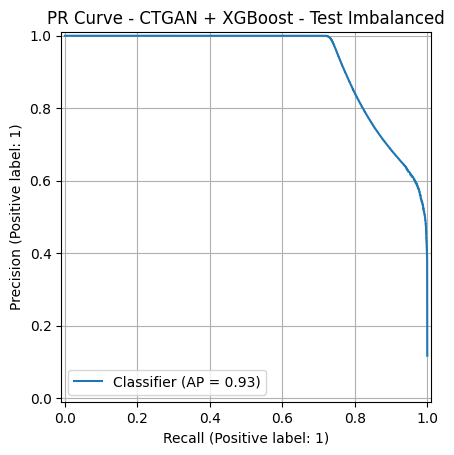

<Figure size 700x500 with 0 Axes>

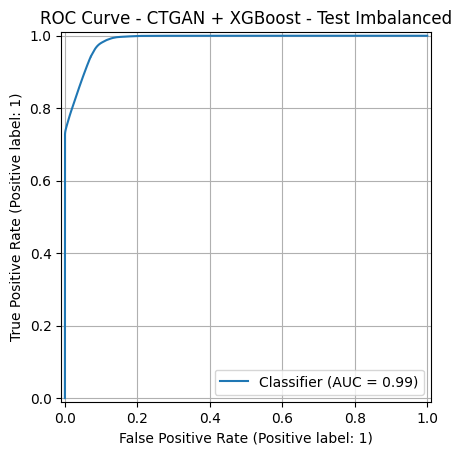

In [22]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

if RUN_FULL_CTGAN:
    plt.figure(figsize=(7,5))
    PrecisionRecallDisplay.from_predictions(y_test_work, score_test_imb)
    plt.title('PR Curve - CTGAN + XGBoost - Test Imbalanced')
    plt.grid(True)
    plt.savefig(OUT_DIR / 'pr_curve_ctgan_imbalanced.png', dpi=160, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(7,5))
    RocCurveDisplay.from_predictions(y_test_work, score_test_imb)
    plt.title('ROC Curve - CTGAN + XGBoost - Test Imbalanced')
    plt.grid(True)
    plt.savefig(OUT_DIR / 'roc_curve_ctgan_imbalanced.png', dpi=160, bbox_inches='tight')
    plt.show()
else:
    print('RUN_FULL_CTGAN=False')


## 17. Salvar relatório JSON

In [23]:
report = {
    'dataset': {
        'X_train_shape': tuple(X_train.shape),
        'X_test_shape': tuple(X_test.shape),
        'train_counts_original': train_counts,
        'test_counts_original': test_counts,
        'work_train_counts': class_counts(y_train_work),
        'model_train_counts': class_counts(y_train_model),
        'threshold_validation_counts': class_counts(y_val_threshold),
        'test_balanced_counts': class_counts(y_test_bal),
    },
    'params': {
        'xgboost': XGB_PARAMS,
        'ctgan': {
            'embedding_dim': CTGAN_EMBEDDING_DIM,
            'generator_dim': CTGAN_GENERATOR_DIM,
            'discriminator_dim': CTGAN_DISCRIMINATOR_DIM,
            'batch_size': CTGAN_BATCH_SIZE,
            'epochs': CTGAN_EPOCHS,
            'pac': CTGAN_PAC,
        },
        'quick_mode': QUICK_MODE,
        'run_full_ctgan': RUN_FULL_CTGAN,
        'use_validation_split': USE_VALIDATION_SPLIT,
        'validation_size': VALIDATION_SIZE,
        'apply_minmax_normalization': APPLY_MINMAX_NORMALIZATION,
        'synthetic_strategy': SYNTHETIC_STRATEGY,
        'clip_synthetic_to_attack_range': CLIP_SYNTHETIC_TO_ATTACK_RANGE,
        'target_recall': TARGET_RECALL,
        'fbeta_beta': FBETA_BETA,
    }
}

# Adiciona resultados ao JSON se os CSVs existirem.
results = {}
for name, csv_name in [
    ('baseline', 'baseline_results.csv'),
    ('ctgan_xgboost', 'ctgan_xgboost_results.csv'),
    ('comparison', 'all_results_comparison.csv'),
]:
    path = OUT_DIR / csv_name
    if path.exists():
        results[name] = pd.read_csv(path).to_dict(orient='records')
report['results'] = results

with open(OUT_DIR / 'experiment_report.json', 'w') as f:
    json.dump(report, f, indent=2, default=str)

print('Arquivos salvos em:', OUT_DIR)
!ls -lh /content/outputs_someip_xgboost


Arquivos salvos em: /content/outputs_someip_xgboost
total 268M
-rw-r--r-- 1 root root 2.8K Apr 30 01:54 all_results_comparison.csv
-rw-r--r-- 1 root root 1.5K Apr 30 00:38 baseline_results.csv
-rw-r--r-- 1 root root 979K Apr 30 01:02 ctgan_attack_only.joblib
-rw-r--r-- 1 root root 1.5K Apr 30 01:54 ctgan_xgboost_results.csv
-rw-r--r-- 1 root root  14K Apr 30 01:55 experiment_report.json
-rw-r--r-- 1 root root  903 Apr 30 00:37 minmax_scaler.joblib
-rw-r--r-- 1 root root  46K Apr 30 01:55 pr_curve_ctgan_imbalanced.png
-rw-r--r-- 1 root root  47K Apr 30 01:55 roc_curve_ctgan_imbalanced.png
-rw-r--r-- 1 root root 259M Apr 30 01:49 synthetic_attacks.npy
-rw-r--r-- 1 root root 3.8M Apr 30 00:38 xgb_baseline_no_ctgan.joblib
-rw-r--r-- 1 root root 3.4M Apr 30 01:53 xgb_ctgan_augmented.joblib


## Observações práticas

- Se o Colab reiniciar por falta de RAM, primeiro rode com `QUICK_MODE=True`.
- Para reprodução final, use Colab Pro/Pro+ ou máquina local com bastante RAM.
- O threshold final agora é escolhido em uma validação estratificada do lado de treino (`X_val_threshold`), não no teste.
- A normalização Min-Max é aplicada com `fit` apenas no treino do modelo e `transform` em validação/teste.
- A estratégia `SYNTHETIC_STRATEGY='paper_table'` gera aproximadamente uma quantidade de ataques sintéticos igual ao número de normais, reproduzindo a Tabela 3 do artigo.
- Também são salvos resultados com threshold por F1, F-beta e recall alvo, permitindo avaliar o trade-off entre falso positivo e falso negativo.


In [30]:
# Se ainda não existir X_test_scaled
X_test_scaled = scaler.transform(X_test)

y_test_proba_baseline = xgb_baseline.predict_proba(X_test_scaled)[:, 1]
y_test_proba_ctgan = xgb_ctgan.predict_proba(X_test_scaled)[:, 1]

In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

def evaluate_paper_style(y_true, proba, threshold, label):
    y_pred = (proba >= threshold).astype(int)

    return {
        "label": label,
        "threshold": float(threshold),

        # Métricas da classe ataque
        "attack_precision": precision_score(y_true, y_pred, pos_label=1),
        "attack_recall": recall_score(y_true, y_pred, pos_label=1),
        "attack_f1": f1_score(y_true, y_pred, pos_label=1),

        # Métricas no estilo provavelmente usado pelo paper
        "weighted_precision": precision_score(y_true, y_pred, average="weighted"),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),

        # Complementar
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
    }

In [32]:
paper_style_baseline = evaluate_paper_style(
    y_test,
    y_test_proba_baseline,
    0.43077653646469116,
    "baseline_paper_style_imbalanced"
)

paper_style_ctgan = evaluate_paper_style(
    y_test,
    y_test_proba_ctgan,
    0.399446040391922,
    "ctgan_paper_style_imbalanced"
)

paper_style_baseline, paper_style_ctgan

({'label': 'baseline_paper_style_imbalanced',
  'threshold': 0.43077653646469116,
  'attack_precision': 0.9884222514744408,
  'attack_recall': 0.7371862664063074,
  'attack_f1': 0.8445151975631523,
  'weighted_precision': 0.9689518275066034,
  'weighted_recall': 0.9682974052622623,
  'weighted_f1': 0.9662515591345895,
  'macro_f1': 0.9134322246761047,
  'accuracy': 0.9682974052622623},
 {'label': 'ctgan_paper_style_imbalanced',
  'threshold': 0.399446040391922,
  'attack_precision': 0.9867477101770624,
  'attack_recall': 0.7367399017516504,
  'attack_f1': 0.8436108342385745,
  'weighted_precision': 0.9687027257970092,
  'weighted_recall': 0.9680981548541011,
  'weighted_f1': 0.9660471298946993,
  'macro_f1': 0.9129241059547748,
  'accuracy': 0.9680981548541011})

## 17. Reproducao do Figure 10 do artigo

Layout 2×2 identico ao artigo: ROC, PR, F1 vs threshold (com 3 marcadores), DET curve. Cada painel sobrerpoe os cenarios imbalanced (azul) e balanced (vermelho).

**Diferenca esperada nos thresholds:** o artigo reporta threshold de treino = 0.364 (otimizando F1 da classe ataque no proprio conjunto de treino). Na reproducao, `threshold_base` e otimizado por F1 ponderado em 10% de validacao separado, resultando em ~0.431. Os thresholds oracle (paineis c) sao calculados retrospectivamente em cada conjunto de teste, tal como o artigo.

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, f1_score, auc as sk_auc
import numpy as np
import matplotlib.pyplot as plt

# ── Scores do baseline (modelo ja treinado na Secao 8) ──────────────────────
score_imb = xgb_baseline.predict_proba(X_test_work)[:, 1]  # teste desbalanceado
score_bal = xgb_baseline.predict_proba(X_test_bal)[:, 1]   # teste balanceado
y_imb     = y_test_work
y_bal     = y_test_bal

# ── Thresholds ──────────────────────────────────────────────────────────────
# 1) Threshold de treino: otimizado no conjunto de validacao (lado treino)
thr_train = threshold_base   # ~0.431 na reproducao (paper: 0.364)

# 2) Oracle thresholds: otimo retrospectivo em cada conjunto de teste
#    (como o artigo — encontrado avaliando weighted F1 sobre o proprio teste)
def oracle_threshold(y_true, scores, n_points=500):
    grid = np.linspace(0.01, 0.99, n_points)
    f1s  = [f1_score(y_true, (scores >= t).astype(int), average='weighted', zero_division=0)
            for t in grid]
    best = int(np.argmax(f1s))
    return grid[best], np.array(f1s), grid

thr_oracle_imb, f1_curve_imb, thr_grid = oracle_threshold(y_imb, score_imb)
thr_oracle_bal, f1_curve_bal, _         = oracle_threshold(y_bal, score_bal)

print(f"Threshold (treino/val):          {thr_train:.4f}  (paper: 0.3640)")
print(f"Oracle threshold (imbalanced):   {thr_oracle_imb:.4f}  (paper: 0.4310)")
print(f"Oracle threshold (balanced):     {thr_oracle_bal:.4f}  (paper: 0.1690)")

# ── Curvas ROC ──────────────────────────────────────────────────────────────
fpr_imb, tpr_imb, _ = roc_curve(y_imb, score_imb)
fpr_bal, tpr_bal, _ = roc_curve(y_bal, score_bal)
auc_roc_imb = sk_auc(fpr_imb, tpr_imb)
auc_roc_bal = sk_auc(fpr_bal, tpr_bal)

# ── Curvas PR ───────────────────────────────────────────────────────────────
prec_imb, rec_imb, _ = precision_recall_curve(y_imb, score_imb)
prec_bal, rec_bal, _ = precision_recall_curve(y_bal, score_bal)
ap_imb = average_precision_score(y_imb, score_imb)
ap_bal = average_precision_score(y_bal, score_bal)
baseline_prec = float(y_imb.mean())   # proporcao da classe positiva (referencia no PR)

# ── DET: FPR x FNR ──────────────────────────────────────────────────────────
fnr_imb = 1.0 - tpr_imb
fnr_bal = 1.0 - tpr_bal
# AUC da DET: area sob a curva FPR-FNR (menor = melhor)
sort_i = np.argsort(fpr_imb)
sort_b = np.argsort(fpr_bal)
auc_det_imb = sk_auc(fpr_imb[sort_i], fnr_imb[sort_i])
auc_det_bal = sk_auc(fpr_bal[sort_b], fnr_bal[sort_b])

# ── Plot 2x2 (reproducao Figure 10) ─────────────────────────────────────────
C_IMB = '#1f77b4'   # azul  — cenario imbalanced
C_BAL = '#d62728'   # vermelho — cenario balanced

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Figure 10 — Comprehensive performance measures (reproducao Kim et al. 2026)',
             fontsize=13, y=1.01)

# (a) ROC curve
ax = axes[0, 0]
ax.plot(fpr_imb, tpr_imb, color=C_IMB, lw=1.5, label=f'imbalanced (AUC={auc_roc_imb:.4f})')
ax.plot(fpr_bal, tpr_bal, color=C_BAL, lw=1.5, label=f'balanced (AUC={auc_roc_bal:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('(a) ROC curve')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# (b) Precision-Recall curve
ax = axes[0, 1]
ax.plot(rec_imb, prec_imb, color=C_IMB, lw=1.5, label=f'imbalanced (AP={ap_imb:.4f})')
ax.plot(rec_bal, prec_bal, color=C_BAL, lw=1.5, label=f'balanced (AP={ap_bal:.4f})')
ax.axhline(baseline_prec, color=C_IMB, linestyle='--', lw=0.8,
           label=f'baseline ({baseline_prec:.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('(b) Precision-Recall curve')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# (c) F1-score vs threshold
ax = axes[1, 0]
ax.plot(thr_grid, f1_curve_imb, color=C_IMB, lw=1.5,
        label='weighted F1 (on test, imbalanced)')
ax.plot(thr_grid, f1_curve_bal, color=C_BAL, lw=1.5,
        label='weighted F1 (on test, balanced)')
ax.axvline(thr_train,      color='gray', linestyle='--',  lw=1.2,
           label=f'Best t by F1(pos=1, train) = {thr_train:.4f}')
ax.axvline(thr_oracle_imb, color=C_IMB, linestyle='-.', lw=1.2,
           label=f'Best t by weighted F1 (test, imbalanced) = {thr_oracle_imb:.4f}')
ax.axvline(thr_oracle_bal, color=C_BAL, linestyle='-.', lw=1.2,
           label=f'Best t by weighted F1 (test, balanced) = {thr_oracle_bal:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('weighted F1-score')
ax.set_title('(c) F1-score versus threshold')
ax.legend(loc='lower left', fontsize=7.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

# (d) Detection Error Tradeoff (DET) curve — FPR x FNR
ax = axes[1, 1]
ax.plot(fpr_imb, fnr_imb, color=C_IMB, lw=1.5, label=f'imbalanced (AUC={auc_det_imb:.4f})')
ax.plot(fpr_bal, fnr_bal, color=C_BAL, lw=1.5, label=f'balanced (AUC={auc_det_bal:.4f})')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('False Negative Rate')
ax.set_title('(d) Detection Error Tradeoff curve')
ax.set_xlim(0, 0.7); ax.set_ylim(0, 0.35)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure10_reproducao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em figure10_reproducao.png')


## 18. Comparação com outros algoritmos (Seção 6.3 do artigo)

O artigo compara o XGBoost contra 9 baselines: RF, DT, LR, LGB, NB, KNN, AE, IF e LOF.
As métricas reportadas são **weighted** precision/recall/F1 e PR-AUC no conjunto de teste desbalanceado.

**Notas de reprodução:**
- Modelos rápidos (DT, LR, NB, LGB, IF) são treinados no conjunto completo (~6.4M amostras).
- RF é treinado em subamostra estratificada (configurável via `N_COMPARISON_TRAIN`) por custo de RAM.
- KNN e LOF são avaliados em subamostra do teste — no artigo, KNN levou 11.412s e LOF 5.295s numa workstation de ponta; em Colab seriam impraticáveis no dataset completo.
- AE (Autoencoder) é treinado apenas sobre amostras normais do treino; o erro de reconstrução é usado como score de anomalia.

In [ ]:
!pip install -q lightgbm

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
)

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('[AVISO] LightGBM nao disponivel. Instale com: pip install lightgbm')

# ── Tamanho do treino para modelos com custo alto de RAM/tempo ─────────────────
# RF pode causar OOM no Colab com 6.4M amostras. Ajuste conforme RAM disponivel.
N_COMPARISON_TRAIN = 1_000_000   # amostras para RF
N_KNN_TRAIN        =   100_000   # amostras para KNN (treino e teste)
N_LOF_FIT          =    50_000   # amostras para LOF

# ── Funcoes auxiliares ─────────────────────────────────────────────────────────
def stratified_sample(X, y, n, seed=42):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    idx = []
    for c in classes:
        ci = np.where(y == c)[0]
        k = max(1, int(round(n * len(ci) / len(y))))
        k = min(k, len(ci))
        idx.append(rng.choice(ci, k, replace=False))
    idx = np.concatenate(idx)
    rng.shuffle(idx)
    return X[idx], y[idx]

def threshold_from_val(y_val, score_val):
    """Otimiza threshold por F1 no conjunto de validacao."""
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_val, score_val)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[np.nanargmax(f1)])

def eval_comparison(name, y_true, y_score, threshold):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return {
        'model':     name,
        'threshold': round(threshold, 4),
        'precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'f1':        round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'pr_auc':    round(average_precision_score(y_true, y_score), 4),
        'attack_f1': round(f1_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'attack_recall': round(recall_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
    }

comparison_results = []
print('Configuracao pronta. Inicie as celulas de cada modelo.')

### 18.1 XGBoost (referencia — ja treinado)

In [ ]:
# XGBoost baseline (sem CTGAN) — modelo ja treinado na Secao 8
score_xgb = xgb_baseline.predict_proba(X_test_work)[:, 1]
thr_xgb = threshold_from_val(y_val_threshold, xgb_baseline.predict_proba(X_val_threshold)[:, 1])
res_xgb = eval_comparison('XGB', y_test_work, score_xgb, thr_xgb)
comparison_results.append(res_xgb)
print(res_xgb)

### 18.2 LightGBM

In [ ]:
if HAS_LGB:
    t0 = time.time()
    lgb_model = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgb_model.fit(X_train_model, y_train_model)
    print(f'LGB treino: {time.time()-t0:.1f}s')

    t0 = time.time()
    score_lgb = lgb_model.predict_proba(X_test_work)[:, 1]
    print(f'LGB teste: {time.time()-t0:.1f}s')

    thr_lgb = threshold_from_val(y_val_threshold, lgb_model.predict_proba(X_val_threshold)[:, 1])
    res_lgb = eval_comparison('LGB', y_test_work, score_lgb, thr_lgb)
    comparison_results.append(res_lgb)
    print(res_lgb)
else:
    print('LightGBM nao disponivel.')

### 18.3 Random Forest

Treinado em subamostra estratificada (`N_COMPARISON_TRAIN`) para evitar OOM no Colab.

In [ ]:
X_rf_train, y_rf_train = stratified_sample(X_train_model, y_train_model, N_COMPARISON_TRAIN)
X_rf_val,   y_rf_val   = stratified_sample(X_val_threshold, y_val_threshold, min(100_000, len(y_val_threshold)))
print(f'RF treino: {X_rf_train.shape}  val: {X_rf_val.shape}')

t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                   random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_rf_train, y_rf_train)
print(f'RF treino: {time.time()-t0:.1f}s')

t0 = time.time()
score_rf = rf_model.predict_proba(X_test_work)[:, 1]
print(f'RF teste: {time.time()-t0:.1f}s')

thr_rf = threshold_from_val(y_rf_val, rf_model.predict_proba(X_rf_val)[:, 1])
res_rf = eval_comparison('RF', y_test_work, score_rf, thr_rf)
comparison_results.append(res_rf)
print(res_rf)

### 18.4 Decision Tree

In [ ]:
t0 = time.time()
dt_model = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
dt_model.fit(X_train_model, y_train_model)
print(f'DT treino: {time.time()-t0:.1f}s')

t0 = time.time()
score_dt = dt_model.predict_proba(X_test_work)[:, 1]
print(f'DT teste: {time.time()-t0:.1f}s')

thr_dt = threshold_from_val(y_val_threshold, dt_model.predict_proba(X_val_threshold)[:, 1])
res_dt = eval_comparison('DT', y_test_work, score_dt, thr_dt)
comparison_results.append(res_dt)
print(res_dt)

### 18.5 Logistic Regression

In [ ]:
t0 = time.time()
lr_model = LogisticRegression(max_iter=500, random_state=RANDOM_STATE, n_jobs=-1)
lr_model.fit(X_train_model, y_train_model)
print(f'LR treino: {time.time()-t0:.1f}s')

t0 = time.time()
score_lr = lr_model.predict_proba(X_test_work)[:, 1]
print(f'LR teste: {time.time()-t0:.1f}s')

thr_lr = threshold_from_val(y_val_threshold, lr_model.predict_proba(X_val_threshold)[:, 1])
res_lr = eval_comparison('LR', y_test_work, score_lr, thr_lr)
comparison_results.append(res_lr)
print(res_lr)

### 18.6 Naive Bayes

In [ ]:
t0 = time.time()
nb_model = GaussianNB()
nb_model.fit(X_train_model, y_train_model)
print(f'NB treino: {time.time()-t0:.1f}s')

t0 = time.time()
score_nb = nb_model.predict_proba(X_test_work)[:, 1]
print(f'NB teste: {time.time()-t0:.1f}s')

thr_nb = threshold_from_val(y_val_threshold, nb_model.predict_proba(X_val_threshold)[:, 1])
res_nb = eval_comparison('NB', y_test_work, score_nb, thr_nb)
comparison_results.append(res_nb)
print(res_nb)

### 18.7 KNN

Treinado e avaliado em subamostra (`N_KNN_TRAIN`) — no artigo levou 11.412s no dataset completo com CPU Threadripper 7970X.

In [ ]:
X_knn_tr, y_knn_tr = stratified_sample(X_train_model, y_train_model, N_KNN_TRAIN)
X_knn_val, y_knn_val = stratified_sample(X_val_threshold, y_val_threshold, min(20_000, len(y_val_threshold)))
X_knn_te, y_knn_te = stratified_sample(X_test_work, y_test_work, N_KNN_TRAIN)
print(f'KNN treino: {X_knn_tr.shape}  val: {X_knn_val.shape}  teste: {X_knn_te.shape}')

t0 = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_knn_tr, y_knn_tr)
print(f'KNN fit: {time.time()-t0:.1f}s')

t0 = time.time()
score_knn = knn_model.predict_proba(X_knn_te)[:, 1]
print(f'KNN predict: {time.time()-t0:.1f}s  (subamostra {N_KNN_TRAIN:,})')

thr_knn = threshold_from_val(y_knn_val, knn_model.predict_proba(X_knn_val)[:, 1])
res_knn = eval_comparison('KNN*', y_knn_te, score_knn, thr_knn)
res_knn['note'] = f'subamostra {N_KNN_TRAIN:,} (dataset completo inviavel em Colab)'
comparison_results.append(res_knn)
print(res_knn)

### 18.8 Autoencoder (AE)

Treinado apenas sobre trafego normal (unsupervised). Score = erro de reconstrucao (MSE por amostra). Threshold selecionado no conjunto de validacao maximizando F1.

In [ ]:
t0 = time.time()

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
AE_EPOCHS = 20
AE_BATCH  = 2048

class SimpleAE(nn.Module):
    def __init__(self, n_in):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, 64), nn.ReLU(),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 16),   nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),   nn.ReLU(),
            nn.Linear(32, 64),   nn.ReLU(),
            nn.Linear(64, n_in),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

X_ae_normal = X_train_model[y_train_model == 0].astype("float32")
print(f"AE: treinando em {len(X_ae_normal):,} amostras normais (device={DEVICE})")

ae_model  = SimpleAE(X_ae_normal.shape[1]).to(DEVICE)
optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

ds     = TensorDataset(torch.tensor(X_ae_normal))
loader = DataLoader(ds, batch_size=AE_BATCH, shuffle=True)

ae_model.train()
for epoch in range(AE_EPOCHS):
    epoch_loss = 0.0
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(ae_model(xb), xb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1}/{AE_EPOCHS}  loss={epoch_loss/len(X_ae_normal):.6f}")

print(f"AE treino: {time.time()-t0:.1f}s")

def ae_score(model, X):
    model.eval()
    with torch.no_grad():
        xt  = torch.tensor(X.astype("float32")).to(DEVICE)
        rec = model(xt).cpu().numpy()
    return ((X - rec) ** 2).mean(axis=1)

score_ae_val  = ae_score(ae_model, X_val_threshold.astype("float32"))
score_ae_test = ae_score(ae_model, X_test_work.astype("float32"))
thr_ae = threshold_from_val(y_val_threshold, score_ae_val)
res_ae = eval_comparison("AE", y_test_work, score_ae_test, thr_ae)
comparison_results.append(res_ae)
print("AE:", res_ae)
print(f"AE total: {time.time()-t0:.1f}s")


### 18.9 Isolation Forest (IF)

Unsupervised. Score = `-decision_function` (maior = mais anomalo). Subamostra de 500k para controlar memoria.

In [ ]:
from sklearn.ensemble import IsolationForest

t0 = time.time()
N_IF_TRAIN = 500_000
X_if_tr, y_if_tr = stratified_sample(X_train_model, y_train_model, N_IF_TRAIN)

if_model = IsolationForest(n_estimators=100, contamination="auto",
                            random_state=RANDOM_STATE, n_jobs=-1)
if_model.fit(X_if_tr)
print(f"IF treino: {time.time()-t0:.1f}s")

score_if_val  = -if_model.decision_function(X_val_threshold)
score_if_test = -if_model.decision_function(X_test_work)
thr_if = threshold_from_val(y_val_threshold, score_if_val)
res_if = eval_comparison("IF*", y_test_work, score_if_test, thr_if)
res_if["note"] = f"subamostra treino {N_IF_TRAIN:,}"
comparison_results.append(res_if)
print("IF:", res_if)
print(f"IF total: {time.time()-t0:.1f}s")


### 18.10 LOF (Local Outlier Factor)

Unsupervised. Score = `-negative_outlier_factor_`. Avaliado em subamostra (`N_LOF_FIT`) — no artigo levou 5.295s no dataset completo; inviavel em Colab sem subamostragem.

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

t0 = time.time()
X_lof_te,  y_lof_te  = stratified_sample(X_test_work,     y_test_work,     N_LOF_FIT)
X_lof_val, y_lof_val = stratified_sample(X_val_threshold, y_val_threshold,
                                          min(20_000, len(y_val_threshold)))

# LOF (novelty=False): fit+predict no mesmo conjunto.
# Concatenamos val+test para obter scores em ambos de uma so vez.
X_lof_all = np.vstack([X_lof_val, X_lof_te])
lof_model = LocalOutlierFactor(n_neighbors=5, contamination="auto", n_jobs=-1, novelty=False)
lof_model.fit_predict(X_lof_all)
lof_scores = -lof_model.negative_outlier_factor_

n_val          = len(X_lof_val)
score_lof_val  = lof_scores[:n_val]
score_lof_test = lof_scores[n_val:]

thr_lof = threshold_from_val(y_lof_val, score_lof_val)
res_lof = eval_comparison("LOF*", y_lof_te, score_lof_test, thr_lof)
res_lof["note"] = f"subamostra {N_LOF_FIT:,} (dataset completo inviavel em Colab)"
comparison_results.append(res_lof)
print("LOF:", res_lof)
print(f"LOF total: {time.time()-t0:.1f}s")


### 18.11 Tabela comparativa e graficos

Reproducao da Tabela 6 e Figuras 11/12 do artigo. Modelos marcados com `*` foram avaliados em subamostra (ver coluna `note` no CSV).

In [ ]:
# ---- Tabela comparativa ----
df_cmp  = pd.DataFrame(comparison_results)
cols_order = ["model", "threshold", "f1", "precision", "recall",
              "pr_auc", "attack_f1", "attack_recall"]
df_show = df_cmp[[c for c in cols_order if c in df_cmp.columns]]

print("\n=== Comparacao de Modelos (weighted, threshold F1-otimizado no val) ===")
print(df_show.to_string(index=False))

# Notas metodologicas impressas junto com a tabela
DISCRETE_SCORE = {"DT", "NB"}   # predict_proba retorna 0/1; threshold=1.0 equivale a pred hard
SUBSAMPLED     = {"KNN*", "IF*", "LOF*"}

print("\n--- Notas metodologicas ---")
print("Scores continuos (threshold selecionado por F1 no val): XGB, LGB, RF, LR, KNN*, AE, IF*, LOF*")
print("Scores discretos (predict_proba retorna 0/1): DT, NB  ->  threshold=1.0 equivale a pred hard")
print("Modelos marcados com * avaliados em subamostra (ver coluna 'note' no CSV)")
print("AE: threshold proximo de zero indica que MSE do trafego normal ja ultrapassa o limiar minimo")
print("LOF: resultado degradado pela subamostra de 50k; nao comparavel com o artigo")

out_csv = "comparison_algorithms.csv"
df_cmp.to_csv(out_csv, index=False)
print(f"\nResultados salvos em {out_csv}")

# ---- Graficos — Figuras 11/12 do artigo ----
models = df_show["model"].tolist()
x      = np.arange(len(models))
w      = 0.22

# Cores por tipo de modelo
def bar_color(model, base_color, discrete_color="lightcoral", sub_color=None):
    if model in DISCRETE_SCORE:
        return discrete_color
    return base_color

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Comparacao de Algoritmos — SOME/IP IDS (Kim et al. 2026, reproducao)", fontsize=13)

ax = axes[0]
ax.bar(x - w, df_show["precision"], w, label="Precision", color="steelblue")
ax.bar(x,     df_show["recall"],    w, label="Recall",    color="seagreen")
ax.bar(x + w, df_show["f1"],        w, label="F1",        color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score (weighted)")
ax.set_title("Precision / Recall / F1 (weighted)")
ax.legend(loc="lower right", fontsize=8); ax.grid(axis="y", alpha=0.3)
# Marca modelos com pred discreta
for i, m in enumerate(models):
    if m in DISCRETE_SCORE:
        ax.annotate("disc.", (x[i], 0.01), ha="center", fontsize=7, color="gray")

ax2 = axes[1]
ax2.bar(x - w/2, df_show["pr_auc"],    w, label="PR-AUC",      color="mediumpurple")
ax2.bar(x + w/2, df_show["attack_f1"], w, label="F1 (ataque)", color="tomato")
ax2.set_xticks(x); ax2.set_xticklabels(models, rotation=30, ha="right")
ax2.set_ylim(0, 1.05); ax2.set_ylabel("Score")
ax2.set_title("PR-AUC e F1 da Classe Ataque")
ax2.legend(loc="lower right", fontsize=8); ax2.grid(axis="y", alpha=0.3)
for i, m in enumerate(models):
    if m in DISCRETE_SCORE:
        ax2.annotate("disc.", (x[i], 0.01), ha="center", fontsize=7, color="gray")

plt.tight_layout()
plt.savefig("comparison_algorithms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em comparison_algorithms.png")

# ---- Attack Recall especifico ----
fig2, ax3 = plt.subplots(figsize=(10, 4))
colors = ["#c0392b" if m not in DISCRETE_SCORE else "#e67e22" for m in models]
bars = ax3.bar(x, df_show["attack_recall"], color=colors, alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(models, rotation=30, ha="right")
ax3.set_ylim(0, 1.05)
ax3.axhline(0.97, color="navy", linestyle="--", lw=1.2, label="Recall 0.97 (limiar IDS)")
ax3.set_ylabel("Attack Recall"); ax3.set_title("Recall da Classe Ataque por Modelo")

# Legenda manual para cores
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor="#c0392b", alpha=0.85, label="Score continuo"),
    Patch(facecolor="#e67e22", alpha=0.85, label="Pred discreta (DT/NB)"),
    plt.Line2D([0], [0], color="navy", linestyle="--", lw=1.2, label="Recall 0.97 (limiar IDS)"),
]
ax3.legend(handles=legend_els, fontsize=8)
ax3.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, df_show["attack_recall"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("comparison_attack_recall.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em comparison_attack_recall.png")

# ---- Resumo textual ----
print("\n=== Resumo ===")
best_f1     = df_show.loc[df_show["f1"].idxmax()]
best_recall = df_show.loc[df_show["attack_recall"].idxmax()]
print(f"Melhor weighted F1:     {best_f1['model']} = {best_f1['f1']:.4f}")
print(f"Melhor attack recall:   {best_recall['model']} = {best_recall['attack_recall']:.4f}  "
      f"({'pred discreta' if best_recall['model'] in DISCRETE_SCORE else 'score continuo'})")
print(f"Gap XGB vs melhor recall continuo: "
      f"{df_show[~df_show['model'].isin(DISCRETE_SCORE)]['attack_recall'].max():.4f}")
